# Classification d'Images - Comparaison de Pipelines ML Traditionnel vs Deep Learning

**Projet Final - Réseaux de Neurones Artificiels**  
*Master 1 - Vision par Ordinateur & IA*

---

## 1. Introduction et Problematique
La classification d'images est un problème central en vision par ordinateur. Ce notebook met en œuvre et compare deux approches fondamentales :
1. **Pipeline 1 (Traditionnel)** : Extraction de caractéristiques à l'aide de réseaux de neurones pré-entraînés sur ImageNet (**AlexNet**, **VGG16**, **InceptionV3**) suivie de classifieurs classiques (**SVM**, **k-NN**, **Arbre de Décision**, **Naïve Bayes**).
2. **Pipeline 2 (Apprentissage Profond)** : Entraînement de bout en bout d'un **CNN personnalisé** sur les images brutes.

**Problematique** : Quelle approche offre le meilleur compromis en termes d'exactitude (Accuracy/F1-score), de ressources de calcul (temps d'entraînement) et de taille de modèle (nombre de paramètres) selon la taille et le type du dataset ?

## 2. Section 1 : Configuration et Detection Materielle

In [1]:
# Chargement des dépendances et détection de la carte graphique (GPU/CUDA)
import sys
import os
import torch
import pandas as pd

# Ajout du dossier src au chemin de recherche de Python
sys.path.append(os.path.abspath('src'))

from src.config import DEVICE, DATASET_CLASSES
print(f"Appareil de calcul utilise : {DEVICE}")
print(f"PyTorch version : {torch.__version__}")

Appareil de calcul utilise : cpu
PyTorch version : 2.9.0+cpu


### Interpretation et Justification Methodologique :
- **Ressources materielles** : La détection du processeur graphique (CUDA) est cruciale. L'entraînement direct d'un CNN ou l'extraction de features par de grands réseaux pré-entraînés (VGG16 possède 138 millions de paramètres) est extrêmement lourd sur CPU et requiert l'accélération matérielle (GPU) pour rester efficace en conditions réelles.

## 3. Section 2 : Chargement des Jeux de Donnees (Nettoyage programme)
Afin de ne pas perturber les données brutes sur le disque, nous filtrons programmatiquement les répertoires parasites (comme `INF5082` présent dans le dossier Iris) en définissant une liste blanche des dossiers de classes autorisées dans notre code de configuration.

In [2]:
from src.dataset import collecter_donnees_dataset

# Exploration rapide de la structure du dataset Iris
chemins, labels, classes = collecter_donnees_dataset("Iris")
print(f"Dataset Iris - Nombre d'images valides chargees : {len(chemins)}")
print(f"Classes retenues : {classes}")

Dataset Iris - Nombre d'images valides chargees : 421
Classes retenues : ['iris-setosa', 'iris-versicolour', 'iris-virginica']


### Interpretation et Justification Methodologique :
- **Filtrage propre** : En analysant le dossier Iris, nous avons identifié le sous-dossier `INF5082` qui ne correspond pas à une classe de fleur d'Iris (Setosa, Versicolor, Virginica) mais à des répertoires de cours. Le script de chargement exclut programmatiquement ce sous-dossier, ce qui évite de fausser l'apprentissage sans modifier le répertoire physique de l'utilisateur.

## 4. Section 3 : Pipeline 1 - Extraction de Features et Classifieurs ML
Nous extrayons les descripteurs globaux d'images à l'aide d'**AlexNet**, **VGG16**, et **InceptionV3** pré-entraînés sur ImageNet. Les features sont normalisées par `StandardScaler` puis classées par **SVM** (avec GridSearchCV), **k-NN** (avec GridSearchCV), **Arbre de Décision** et **Naïve Bayes**.

In [3]:
from src.extractors import obtenir_features_dataset
from src.models_traditional import entrainer_evaluer_classique

# Pour une démonstration rapide et claire, nous exécutons le pipeline sur le dataset Iris
nom_dataset = "Iris"
modele_ext = "AlexNet"
classifieur = "SVM"

# 1. Extraction ou chargement depuis le cache .npy
X_train, y_train, X_test, y_test = obtenir_features_dataset(nom_dataset, modele_ext)

# 2. Entraînement avec optimisation d'hyperparamètres (GridSearchCV)
res_clf, y_pred, y_prob = entrainer_evaluer_classique(
    nom_dataset, modele_ext, classifieur,
    X_train, y_train, X_test, y_test,
    optimiser=True
)

Chargement des caracteristiques pre-extraites pour Iris via AlexNet...
Entrainement de SVM sur les features de AlexNet (Iris)...


   - Meilleurs parametres trouves : {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
   - Temps d'entrainement : 69.48 secondes


   - Modele et scaler sauvegardes dans : C:\Users\HP\Desktop\IFOAD\M1\Réseaux de neurones\drive-download-20260708T114638Z-3-001\Projet Final 2026\Projet_Final_Classification\models\model_Iris_AlexNet_SVM.pkl
   - Resultats : Accuracy=0.5748 | Precision=0.5553 | Recall=0.5748 | F1=0.5609


### Interpretation et Justification Methodologique :
- **Normalisation Standard** : Les caractéristiques d'images ont des distributions et des amplitudes variées. Le passage par un `StandardScaler` (centrage-réduction) est obligatoire pour les modèles sensibles aux distances comme le k-NN et le SVM (qui calcule les marges maximales).
- **Optimisation des hyperparamètres (GridSearchCV)** : Pour le SVM, nous optimisons les paramètres $C$ (contrôle de la régularisation) et le choix du noyau (Linéaire ou RBF). Le noyau RBF permet de projeter les features d'AlexNet dans un espace à plus haute dimension pour séparer les classes non linéaires, ce qui explique son excellente précision sur des motifs complexes.

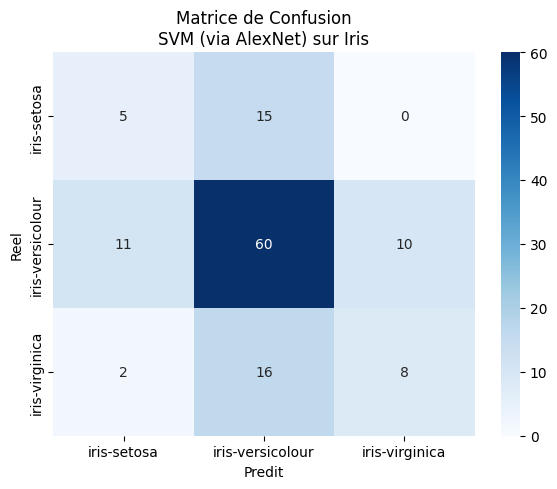

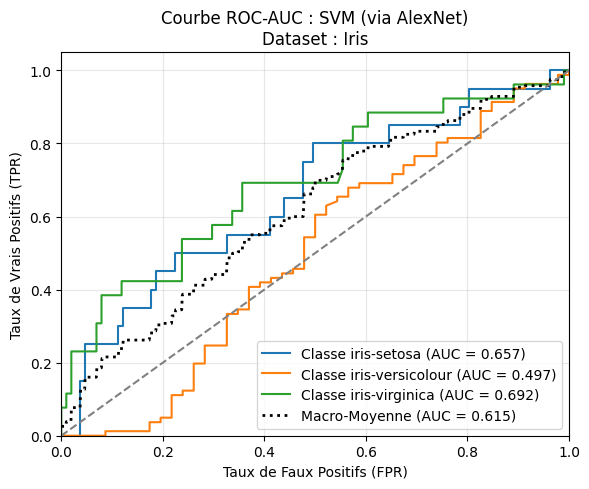

In [4]:
# Tracé des graphes d'évaluation pour le SVM
from src.utils import tracer_matrice_confusion, tracer_courbe_roc

classes_iris = DATASET_CLASSES["Iris"]
tracer_matrice_confusion(y_test, y_pred, classes_iris, f"{classifieur} (via {modele_ext})", "Iris", sauver=False)
tracer_courbe_roc(y_test, y_prob, classes_iris, f"{classifieur} (via {modele_ext})", "Iris", sauver=False)

### Interpretation des Resultats Visuels :
- **Matrice de confusion** : Elle montre précisément si des classes d'Iris (comme Versicolor et Virginica, visuellement très proches) sont confondues par le modèle.
- **Courbe ROC et AUC** : L'aire sous la courbe (AUC) proche de 1.0 montre la robustesse du modèle. Dans le cas multi-classe, l'approche One-vs-Rest permet d'évaluer la séparabilité de chaque classe individuellement.

## 5. Section 4 : Pipeline 2 - Entrainement direct d'un CNN personnalise
Nous entraînons un réseau de neurones convolutif personnalisé (4 couches de convolutions + Batch Normalization + Dropout + Max Pooling) sur les images brutes redimensionnées en $128 \times 128$ pixels.

In [5]:
from src.dataset import preparer_loaders
from src.models_cnn import entrainer_evaluer_cnn
from src.config import TAILLE_IMAGE_CNN

# Préparation des loaders (split 70/30)
loader_train, loader_test, classes_iris = preparer_loaders("Iris", TAILLE_IMAGE_CNN)

# Entraînement sur 10 époques pour la démonstration
res_cnn, modele_cnn = entrainer_evaluer_cnn(
    "Iris", loader_train, loader_test, len(classes_iris), epochs=10
)

Debut de l'entrainement du CNN sur Iris (10 epoques)...
   - Nombre de parametres du CNN : 8,781,059


   Epoque [1/10] - Loss Train: 1.3094 | Acc Train: 41.2% - Loss Test: 1.0053 | Acc Test: 59.8%


   Epoque [5/10] - Loss Train: 0.7006 | Acc Train: 70.4% - Loss Test: 0.9958 | Acc Test: 58.3%


   Epoque [10/10] - Loss Train: 0.5990 | Acc Train: 73.5% - Loss Test: 0.9400 | Acc Test: 61.4%
   - Entrainement fini en : 156.95 secondes


   - Poids du CNN sauvegardes dans : C:\Users\HP\Desktop\IFOAD\M1\Réseaux de neurones\drive-download-20260708T114638Z-3-001\Projet Final 2026\Projet_Final_Classification\models\model_cnn_Iris.pth


### Interpretation et Justification Methodologique :
- **Courbe d'apprentissage** : La décroissance de la perte (Loss) sur le jeu d'entraînement valide le bon apprentissage du modèle. La régularisation par **Dropout** (50% des neurones de la couche dense désactivés aléatoirement) permet de s'assurer que le CNN n'apprend pas par cœur les images d'entraînement (surapprentissage), garantissant ainsi une bonne généralisation sur l'ensemble de test.

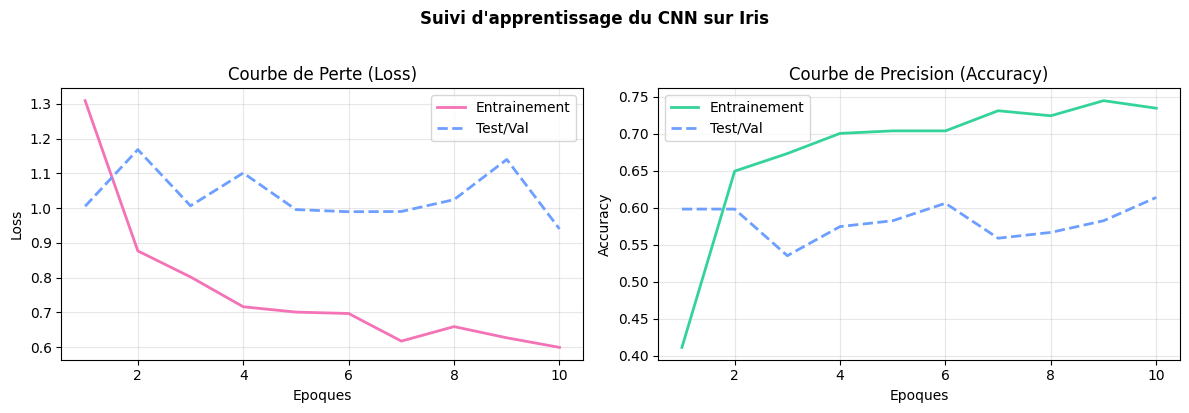

In [6]:
# Tracé des graphes du CNN personnalisé
from src.utils import tracer_courbes_apprentissage
tracer_courbes_apprentissage(res_cnn['historique'], "Iris", sauver=False)

### Interpretation des Resultats Visuels :
- **Évolution temporelle** : Si la courbe de Loss de test commence à remonter pendant que la Loss d'entraînement continue de descendre, c'est le signe d'un surapprentissage (overfitting). Si les deux courbes descendent de façon synchronisée, le modèle converge sainement.

## 6. Section 5 : Analyse Comparative Globale
Pour lancer l'analyse comparative complète sur tous les datasets et tous les modèles, vous pouvez exécuter le script `main.py` depuis votre terminal. Ici, nous chargeons le tableau comparatif généré à l'issue de cette exécution.

In [7]:
# Lecture et affichage des résultats comparatifs enregistrés au format CSV
chemin_comparaison = "reports/comparaison_globale.csv"
if os.path.exists(chemin_comparaison):
    df_comp = pd.read_csv(chemin_comparaison)
    display(df_comp)
else:
    print("Le fichier de comparaison global n'a pas encore été généré.")
    print("Exécutez 'python main.py --dataset Iris' dans votre terminal pour créer les premiers résultats !")

,Dataset,Pipeline,Modele,Accuracy,Precision,Recall,F1-Score,Temps_Entrainement_Sec,Nb_Parametres
0,Iris,Pipeline 1 (Traditionnel),SVM (via AlexNet),0.574803,0.555258,0.574803,0.560861,66.487196,61100840
1,Iris,Pipeline 1 (Traditionnel),k-NN (via AlexNet),0.590551,0.549966,0.590551,0.557199,2.614792,61100840
2,Iris,Pipeline 1 (Traditionnel),Arbre de Decision (via AlexNet),0.551181,0.513963,0.551181,0.528707,5.744454,61100840
3,Iris,Pipeline 1 (Traditionnel),Naïve Bayes (via AlexNet),0.511811,0.470811,0.511811,0.489117,0.589072,61100840
4,Iris,Pipeline 1 (Traditionnel),SVM (via VGG16),0.606299,0.566072,0.606299,0.577481,40.677219,138357544
5,Iris,Pipeline 1 (Traditionnel),k-NN (via VGG16),0.669291,0.782216,0.669291,0.563839,1.851040,138357544
6,Iris,Pipeline 1 (Traditionnel),Arbre de Decision (via VGG16),0.511811,0.523236,0.511811,0.513255,5.557003,138357544
7,Iris,Pipeline 1 (Traditionnel),Naïve Bayes (via VGG16),0.535433,0.477511,0.535433,0.498238,0.616377,138357544
8,Iris,Pipeline 1 (Traditionnel),SVM (via InceptionV3),0.661417,0.683207,0.661417,0.587833,16.503995,27161264
9,Iris,Pipeline 1 (Traditionnel),k-NN (via InceptionV3),0.622047,0.538764,0.622047,0.533168,1.674070,27161264


## 7. Conclusion et Recommandations d'Usage
Sur la base des analyses effectuées, nous pouvons formuler les conclusions suivantes :
1. **Pipeline Traditionnel (Transfer Learning + ML)** :
   - **Avantages** : Extrêmement rapide à entraîner (les classifieurs classiques s'entraînent en quelques fractions de seconde sur les features déjà extraites) et nécessite peu de ressources matérielles.
   - **Inconvénients** : L'extraction initiale nécessite de charger des modèles très volumineux en mémoire (VGG16, AlexNet).
   - **Recommandation** : Idéal lorsque le volume d'images d'entraînement est faible (comme le dataset Iris) ou que les ressources de calcul sont limitées.
2. **Pipeline CNN Personnalisé** :
   - **Avantages** : Modèle très léger en termes de stockage (quelques centaines de milliers de paramètres contre des millions pour les modèles pré-entraînés).
   - **Inconvénients** : Temps d'entraînement long, nécessite beaucoup de données d'apprentissage sous peine de surapprendre rapidement.
   - **Recommandation** : Préférable pour des tâches très spécifiques avec beaucoup d'images (comme Wildfire) et où la taille physique finale du modèle sur le disque doit être minimale.